In [13]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
from atmo3 import grid_utils as gutl
from atmo3 import box
from atmo3 import atm_utils as au
from atmo3 import constants as const
import matplotlib.pyplot as plt

# ==============================================================================
# 1. Define the Geometric Workspace
# ==============================================================================
# Calculate the vertical grid dimensions
Lz = 9750.0  # Total height of the box in meters
dz = 30.0    # Vertical step size in meters
Nz = int(Lz / dz)  # Yields exactly 325 cells

L_0_q = 500 #m


dt_simulation = 2.0  # in seconds
vx = 1.0  # in m/s the wind speed along the x-axis

# Update your N and Lbox arrays (assuming you keep the X and Y axes the same),  we make Nz and Lz match the lidar profiles
N = jnp.array([2048, 256, Nz])                 # [256, 256, 325]
Lbox = jnp.array([40000.0, 20000.0, Lz])      # [20000.0, 20000.0, 9750.0]
site_altitude = 2400.0                        # Your new site altitude

# Initialize the standalone grid workspace
grid_wsp = gutl.GridWorkspace(N=N, Lbox=Lbox, site_altitude=site_altitude)

# Extract the exact 1D altitude axis 
# This will automatically start at 2400m and go up to 12150m (2400 + 9750) with 30m steps
z_axis_grid = grid_wsp.grid_axis(axis=2, altitude_axis=True)

import numpy as np
from lidar_sigma_pwv import lidar_sigma_pwv

data_file = "/pscratch/sd/v/valer/atmo3/notebooks/lidar_noise/Simulation_Tenerife_lidarH2O_15cm_00deg_10s.txt"

zbin = grid_wsp.grid_axis(axis=2, altitude_axis=False) # m

sigma_pwv = lidar_sigma_pwv(
    zbin=zbin,
    dzbin=30.0,
    tsampling=10.0,
    data_file=data_file,
    elevation=90.0,
    telsize=0.15,
    reference_telsize=0.15,
    reference_tsampling=10.0,
)
data = np.loadtxt(data_file, comments=("#", ";"))


s_km = data[:, 0] #in km
z_km = data[:, 1] #in km
q = data[:, 2] # in kg/kg
sigma_wvmr_g_per_kg = data[:, 3] # in g/kg
bias = data[:, 4] # in g/kg
pressure_hpa = data[:, 5] #in hPa
temperature_k = data[:, 6] #in K




kx_max = (grid_wsp.N[0] / 2.0) * grid_wsp.dk[0]
ky_max = (grid_wsp.N[1] / 2.0) * grid_wsp.dk[1]
kz_max = (grid_wsp.N[2] / 2.0) * grid_wsp.dk[2]

# 2. Calculate the extreme corner of the 3D Fourier volume
k_max_3d = np.sqrt(kx_max**2 + ky_max**2 + kz_max**2)

# 3. Create a high-resolution k_array using the smallest dk step
dk_min = np.min(grid_wsp.dk)
n_points = int(k_max_3d / dk_min) + 10  # +10 acts as a safety buffer

k_array = np.arange(n_points) * dk_min

k0_q  = 2*np.pi / L_0_q   # Water-vapour injection wavenumber (rad/m)

pofk_q  = ( k0_q**2.  + k_array**2 )**-(11/6)

# Normalise to peak = 1; absolute RMS amplitudes come from calibration.
pofk_q  /= np.max(pofk_q)

# Pack into dictionaries expected
pspec_q  = {'k': k_array, 'pofk': pofk_q}

# Next, define the fluctuation scaling profile. 
q_std_atmosphere = q

In [14]:
import numpy as np
import jax.numpy as jnp
import jax.random as random
from scipy.signal import csd
from atmo3.observation import Observer
import datetime

# ==============================================================================
# 1. Prepare Pre-Loop Constants & Observation Timelines
# ==============================================================================
N_sim_cube = 100      
y_boresight_array = jnp.array([6000.0, 7000.0, 8000.0, 9000.0, 10000.0, 11000.0, 12000.0, 13000.0, 14000.0]) 
N_sim_boresight = len(y_boresight_array)
total_sims = N_sim_cube * N_sim_boresight

#define y boresight from 6000m to 14000m with 1000m steps




# Signal processing params
n_window = 360
dt_lidar = 10.0
fs_lidar = 1.0 / dt_lidar
frames_per_lidar = int(dt_lidar / dt_simulation)

# Pre-calculate thermodynamic conversion factors once to save compute inside the loop
T_v = au.virtual_temperature(temperature_k, q) 
q2rho_h2o = pressure_hpa * 100.0 / (const.R_dry_air * T_v) 
rho_wv_mean_1d = q * q2rho_h2o
mean_pwv = jnp.trapezoid(rho_wv_mean_1d, x=z_km * 1000)
target_sigma_pwv = 0.01 * mean_pwv

# Interpolate onto the exact internal Z-grid midpoints
q2rho_interp_1d = jnp.interp(z_axis_grid, z_km * 1000, q2rho_h2o, left='extrapolate', right='extrapolate')
mean_interp_1d = jnp.interp(z_axis_grid, z_km * 1000, q, left='extrapolate', right='extrapolate')

# Setup 1-hour timeline
total_duration = 3600 
n_steps = int(total_duration / dt_simulation)
start_time = np.datetime64('2026-01-01T00:00:00')
timelist = [start_time + np.timedelta64(int(i * dt_simulation), 's') for i in range(n_steps)]
azimuth_deg = [0.0] * n_steps
elevation_deg = [90.0] * n_steps

# Dummy passband for Observer initialization
dummy_passband = {'freq_GHz': jnp.array([150.0]), 'g_nu': jnp.array([1.0])}

# Extract the frequency axis length for our master arrays
dummy_data = np.zeros(n_window)
freqs, _ = csd(dummy_data, dummy_data, fs=fs_lidar, nperseg=n_window)
N_freqs = len(freqs)

# ==============================================================================
# 2. Initialize Master Storage Arrays (NumPy to protect VRAM)
# ==============================================================================
# Shape: (Total_Simulations, Nz, N_freqs)
master_cpsd_real = np.zeros((total_sims, Nz, N_freqs))
master_true_psd = np.zeros((total_sims, Nz, N_freqs))
master_noisy_psd = np.zeros((total_sims, Nz, N_freqs))
master_noise_psd = np.zeros((total_sims, Nz, N_freqs))

master_key = random.PRNGKey(42)
sim_counter = 0

print(f"Starting Ensemble: {N_sim_cube} Cubes x {N_sim_boresight} Lanes = {total_sims} Total Runs")

# ==============================================================================
# 3. The Nested Monte Carlo Loop
# ==============================================================================
for cube_idx in range(N_sim_cube):
    print(f"\n--- Generating Atmospheric Cube {cube_idx + 1}/{N_sim_cube} ---")
    
    # 1. Generate a completely independent integer seed for the Box generator
    master_key, atmo_key = random.split(master_key)
    cube_seed = int(random.randint(atmo_key, shape=(), minval=0, maxval=99999999))
    
    # 2. Initialize the Box with the new seed to guarantee uncorrelated turbulence
    wv_box = box.Box(
        grid_wsp=grid_wsp,
        field_name='water vapor',
        field_unit='kg / kg',
        spectrum=pspec_q, 
        zscaling={'h': z_km * 1000, 'f': q_std_atmosphere}, 
        seed=cube_seed 
    )

    wv_box.generate_field_fluctuations(time_step=0)

    # 3. Recalibrate to PWV Targets
    pwv_fluctuation_plane = jnp.trapezoid(wv_box.field * q2rho_interp_1d.reshape(1, 1, -1), x=z_axis_grid, axis=2)
    current_sigma_pwv = jnp.std(pwv_fluctuation_plane)
    
    pwv_norm = target_sigma_pwv / current_sigma_pwv
    wv_box.field = wv_box.field * pwv_norm
    
    # 4. Construct Final 3D Cube
    total_wv_3d = wv_box.field + mean_interp_1d.reshape(1, 1, -1)
    
    # --------------------------------------------------------------------------
    # 4. The Boresight Extraction Loop
    # --------------------------------------------------------------------------
    for bore_idx, y_pos in enumerate(y_boresight_array):
        
        # A. FRESH Observer initialization for this specific lane
        boresight = jnp.array([grid_wsp.Lbox[0] / 2.0, y_pos, grid_wsp.site_altitude])
        obs = Observer(
            grid_wsp=grid_wsp,
            boresight=boresight,
            passband=dummy_passband,
            fwhm_arcmin=1.0
        )
        obs.east_wind = vx   
        obs.north_wind = 0.0 
        
        # B. Extract 2D Slice (Time, Nz)
        obs.compute_los_for_scan(timelist, azimuth_deg, elevation_deg)
        pristine_q_tod = obs.scan_component(total_wv_3d)
        
        # C. Convert entire slice to Layer PWV (kg/m^2)
        true_signal_2s_2d = (pristine_q_tod * q2rho_interp_1d) * dz
        
        # D. Downsample entire 2D array to 10s via Zero-Order Hold averaging
        total_frames = true_signal_2s_2d.shape[0]
        n_lidar_samples = total_frames // frames_per_lidar
        valid_frames = n_lidar_samples * frames_per_lidar
        
        true_10s_blocks = true_signal_2s_2d[:valid_frames, :].reshape(n_lidar_samples, frames_per_lidar, Nz)
        true_signal_1d_2d = jnp.mean(true_10s_blocks, axis=1)
        
        # E. Strictly remove temporal mean for every layer independently (axis=0)
        true_signal_1d_2d -= jnp.mean(true_signal_1d_2d, axis=0)
        
        # F. Generate independent Hardware Noise for all layers
        master_key, noise_key = random.split(master_key)
        current_noise_2d = random.normal(noise_key, shape=true_signal_1d_2d.shape) * sigma_pwv
        current_noise_2d -= jnp.mean(current_noise_2d, axis=0)

        noisy_signal_1d_2d = true_signal_1d_2d + current_noise_2d
        
        # G. Calculate Spectral Densities for ALL layers simultaneously (axis=0)
        _, csd_sx = csd(true_signal_1d_2d, noisy_signal_1d_2d, fs=fs_lidar, nperseg=n_window, axis=0)
        _, csd_xs = csd(noisy_signal_1d_2d, true_signal_1d_2d, fs=fs_lidar, nperseg=n_window, axis=0)
        cpsd_complex = 0.5 * (csd_sx + csd_xs)
        
        _, psd_true_complex = csd(true_signal_1d_2d, true_signal_1d_2d, fs=fs_lidar, nperseg=n_window, axis=0)

        _, psd_noisy_complex = csd(noisy_signal_1d_2d, noisy_signal_1d_2d, fs=fs_lidar, nperseg=n_window, axis=0)
        _, psd_noise_complex = csd(current_noise_2d, current_noise_2d, fs=fs_lidar, nperseg=n_window, axis=0)
        
        # H. Store in the Master Array, transposing to shape (Nz, N_freqs)
        master_true_psd[sim_counter, :, :] = jnp.real(psd_true_complex).T
        master_cpsd_real[sim_counter, :, :] = jnp.real(cpsd_complex).T
        master_noisy_psd[sim_counter, :, :] = jnp.real(psd_noisy_complex).T
        master_noise_psd[sim_counter, :, :] = jnp.real(psd_noise_complex).T
        
        sim_counter += 1
        print(f"  Extracted Lane {bore_idx+1}/{N_sim_boresight} | Total Runs: {sim_counter}/{total_sims}")

print("\nAll simulations successfully stored in master arrays!")

Starting Ensemble: 100 Cubes x 9 Lanes = 900 Total Runs

--- Generating Atmospheric Cube 1/100 ---
Random field : 11.481360 s
Apply P(k) : 11.646522 s
IRFFT : 0.061937 s
Rescaled field : 3.497204 s
  Extracted Lane 1/9 | Total Runs: 1/900
  Extracted Lane 2/9 | Total Runs: 2/900
  Extracted Lane 3/9 | Total Runs: 3/900
  Extracted Lane 4/9 | Total Runs: 4/900
  Extracted Lane 5/9 | Total Runs: 5/900
  Extracted Lane 6/9 | Total Runs: 6/900
  Extracted Lane 7/9 | Total Runs: 7/900
  Extracted Lane 8/9 | Total Runs: 8/900
  Extracted Lane 9/9 | Total Runs: 9/900

--- Generating Atmospheric Cube 2/100 ---
Random field : 10.018390 s
Apply P(k) : 11.938592 s
IRFFT : 0.000892 s
Rescaled field : 3.595578 s
  Extracted Lane 1/9 | Total Runs: 10/900
  Extracted Lane 2/9 | Total Runs: 11/900
  Extracted Lane 3/9 | Total Runs: 12/900
  Extracted Lane 4/9 | Total Runs: 13/900
  Extracted Lane 5/9 | Total Runs: 14/900
  Extracted Lane 6/9 | Total Runs: 15/900
  Extracted Lane 7/9 | Total Runs: 16/9

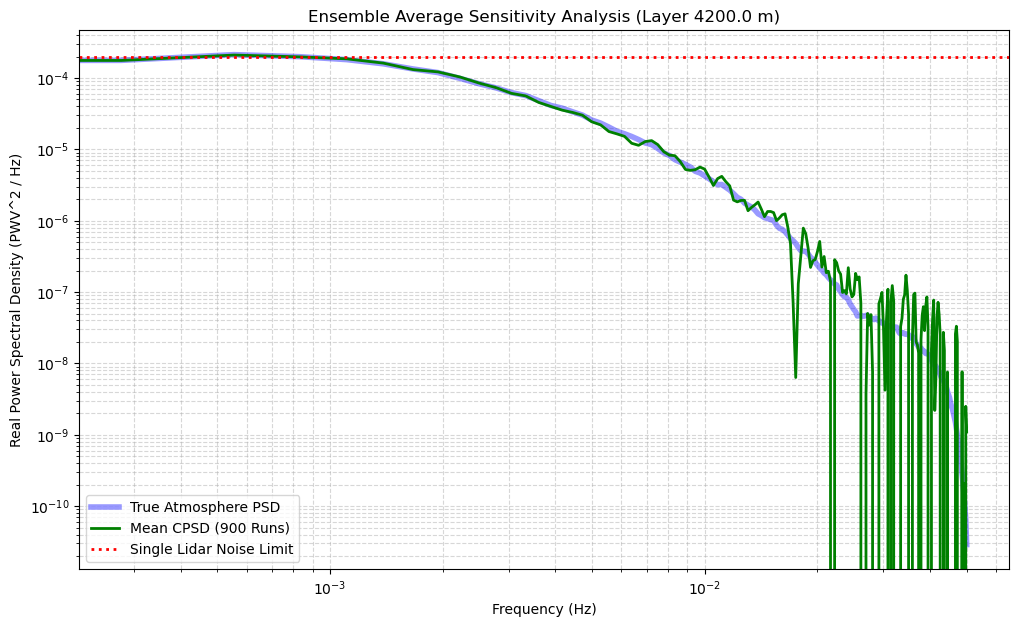

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. Select the Layer
# ==============================================================================
# Choose the altitude layer you want to inspect (e.g., 20 for 3000m)
layer_idx = 60
altitude_m = z_axis_grid[layer_idx]

# ==============================================================================
# 2. Calculate the Ensemble Averages
# ==============================================================================
# Slice the master arrays: [all_simulations, specific_layer, all_frequencies]
# Then take the mean across axis 0 (the simulations)
final_mean_true_psd = np.mean(master_true_psd[:, layer_idx, :], axis=0)
final_mean_cpsd = np.mean(master_cpsd_real[:, layer_idx, :], axis=0)

# Calculate the theoretical noise limit for this specific layer
theoretical_limit = 2.0 * (sigma_pwv[layer_idx]**2) / fs_lidar

# ==============================================================================
# 3. Plot the Final Results
# ==============================================================================
plt.figure(figsize=(12, 7))

# Plot the True Atmosphere (The baseline truth)
plt.loglog(freqs, final_mean_true_psd, label='True Atmosphere PSD', color='blue', linewidth=4, alpha=0.4)

# Plot the Averaged Cross-Spectrum (Your extracted signal)
plt.loglog(freqs, final_mean_cpsd, label=f'Mean CPSD ({total_sims} Runs)', color='green', linewidth=2)

# Plot the Theoretical Single-Run Lidar Noise Floor (The brick wall you bypassed)
plt.axhline(theoretical_limit, color='red', linestyle=':', linewidth=2, label='Single Lidar Noise Limit')

plt.title(f'Ensemble Average Sensitivity Analysis (Layer {altitude_m:.1f} m)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Real Power Spectral Density (PWV^2 / Hz)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

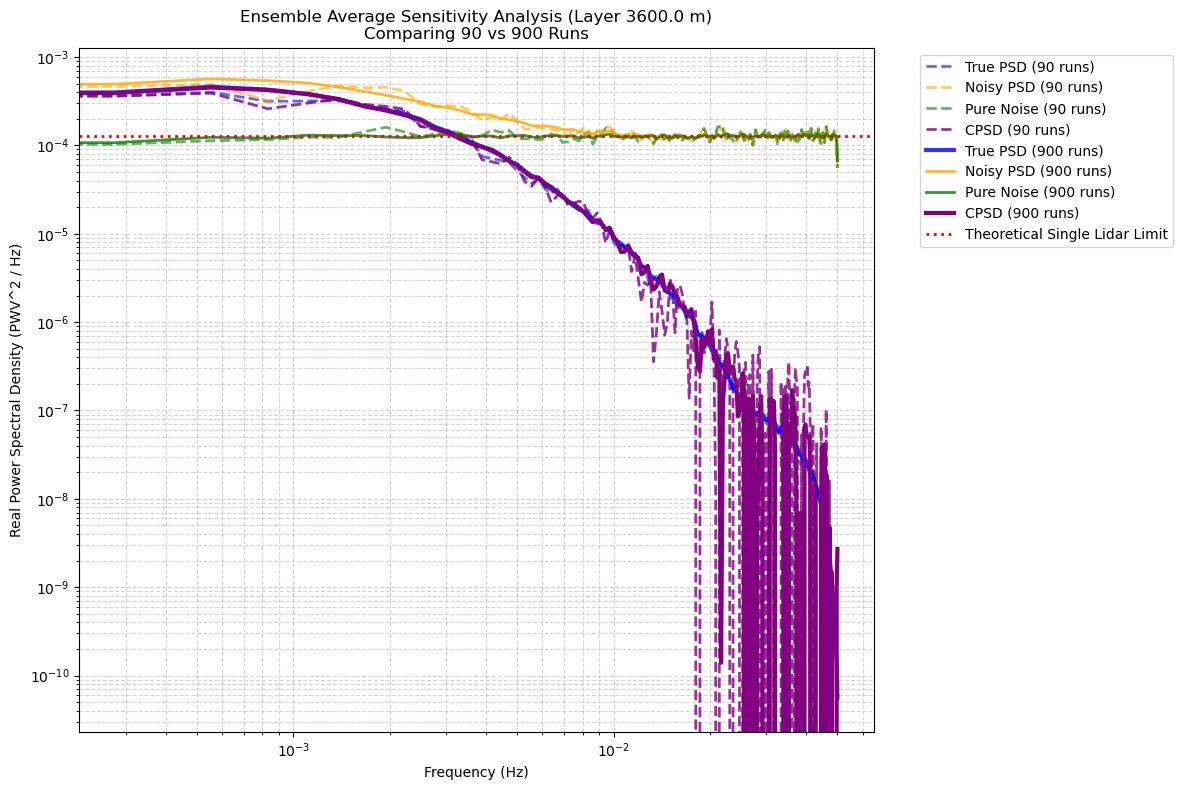

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. Select the Layer & Setup Limits
# ==============================================================================
# Choose the altitude layer you want to inspect
layer_idx = 40
altitude_m = z_axis_grid[layer_idx]
half_sims = 90

# Calculate the theoretical noise limit for this specific layer
theoretical_limit = 2.0 * (sigma_pwv[layer_idx]**2) / fs_lidar

# ==============================================================================
# 2. Calculate the Ensemble Averages (Full vs. Half)
# ==============================================================================
# HALF observation time (First half of the simulations)
half_mean_true = np.mean(master_true_psd[:half_sims, layer_idx, :], axis=0)
half_mean_noisy = np.mean(master_noisy_psd[:half_sims, layer_idx, :], axis=0)
half_mean_noise = np.mean(master_noise_psd[:half_sims, layer_idx, :], axis=0)
half_mean_cpsd = np.mean(master_cpsd_real[:half_sims, layer_idx, :], axis=0)

# FULL observation time (All simulations)
full_mean_true = np.mean(master_true_psd[:, layer_idx, :], axis=0)
full_mean_noisy = np.mean(master_noisy_psd[:, layer_idx, :], axis=0)
full_mean_noise = np.mean(master_noise_psd[:, layer_idx, :], axis=0)
full_mean_cpsd = np.mean(master_cpsd_real[:, layer_idx, :], axis=0)

# ==============================================================================
# 3. Plot the Final Results
# ==============================================================================
plt.figure(figsize=(12, 8))

# --- Plot HALF observation time (Dashed lines) ---
plt.loglog(freqs, half_mean_true, color='blue', linestyle='--', linewidth=2, alpha=0.6, label=f'True PSD ({half_sims} runs)')
plt.loglog(freqs, half_mean_noisy, color='orange', linestyle='--', linewidth=2, alpha=0.6, label=f'Noisy PSD ({half_sims} runs)')
plt.loglog(freqs, half_mean_noise, color='green', linestyle='--', linewidth=2, alpha=0.6, label=f'Pure Noise ({half_sims} runs)')
plt.loglog(freqs, half_mean_cpsd, color='purple', linestyle='--', linewidth=2, alpha=0.8, label=f'CPSD ({half_sims} runs)')

# --- Plot FULL observation time (Solid lines) ---
plt.loglog(freqs, full_mean_true, color='blue', linestyle='-', linewidth=3, alpha=0.8, label=f'True PSD ({total_sims} runs)')
plt.loglog(freqs, full_mean_noisy, color='orange', linestyle='-', linewidth=2, alpha=0.8, label=f'Noisy PSD ({total_sims} runs)')
plt.loglog(freqs, full_mean_noise, color='green', linestyle='-', linewidth=2, alpha=0.8, label=f'Pure Noise ({total_sims} runs)')
plt.loglog(freqs, full_mean_cpsd, color='purple', linestyle='-', linewidth=3, alpha=1.0, label=f'CPSD ({total_sims} runs)')

# --- Plot the Theoretical Reference ---
plt.axhline(theoretical_limit, color='red', linestyle=':', linewidth=2, label='Theoretical Single Lidar Limit')

plt.title(f'Ensemble Average Sensitivity Analysis (Layer {altitude_m:.1f} m)\nComparing {half_sims} vs {total_sims} Runs')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Real Power Spectral Density (PWV^2 / Hz)')
plt.grid(True, which="both", ls="--", alpha=0.5)

# Place the legend outside the plot so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.show()

In [23]:
import numpy as np

output_path = '/pscratch/sd/v/valer/atmo3/notebooks/lidar_noise/multiple_sim_crossspec.npz'

np.savez_compressed(
    output_path,
    master_true_psd=master_true_psd,
    master_noisy_psd=master_noisy_psd,
    master_noise_psd=master_noise_psd,
    master_cpsd_real=master_cpsd_real,
    freqs=freqs,
 )

print(f'Saved arrays to {output_path}')

# Later, open the file with:
 # data = np.load(output_path)
 # master_true_psd = data['master_true_psd']
 # master_noisy_psd = data['master_noisy_psd']
 # master_noise_psd = data['master_noise_psd']
 # master_cpsd_real = data['master_cpsd_real']
 # freqs = data['freqs']

Saved arrays to /pscratch/sd/v/valer/atmo3/notebooks/lidar_noise/multiple_sim_crossspec.npz


## Reloading the saved arrays

Use this later to open the file from the notebook directory:

```python
data = np.load('/pscratch/sd/v/valer/atmo3/notebooks/lidar_noise/multiple_sim_crossspec.npz')
master_true_psd = data['master_true_psd']
master_noisy_psd = data['master_noisy_psd']
master_noise_psd = data['master_noise_psd']
master_cpsd_real = data['master_cpsd_real']
freqs = data['freqs']
```